04 - Machine Learning

This notebook applies machine learning to the COVID-19 Romania county-level dataset.

The goal is to predict the risk level of a county record based on COVID-19 indicators.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries imported successfully.")

Libraries imported successfully.


STEP 1 - Load the Processed Dataset

The cleaned county-level dataset is loaded from the processed folder.

In [2]:
file_path = "../data/processed/covid_county_clean.csv"

df = pd.read_csv(file_path)

print("Dataset loaded.")
print("Shape:", df.shape)

df.head()


Dataset loaded.
Shape: (4624, 8)


,County,Confirmed,Date,Year,Month,Month_Name,Day,Risk_Level
0,Alba,9,2020-04-02,2020,4,April,2,Low
1,Alba,13,2020-04-03,2020,4,April,3,Low
2,Alba,15,2020-04-04,2020,4,April,4,Low
3,Alba,33,2020-04-05,2020,4,April,5,Low
4,Alba,34,2020-04-06,2020,4,April,6,Low


STEP 2 - Select Columns for Machine Learning

The model uses county, confirmed cases, year, and month to predict the risk level.

In [3]:
ml_data = df[["County", "Confirmed", "Year", "Month", "Risk_Level"]].copy()

print("Machine learning data selected.")
print("Shape:", ml_data.shape)

ml_data.head()

Machine learning data selected.
Shape: (4624, 5)


,County,Confirmed,Year,Month,Risk_Level
0,Alba,9,2020,4,Low
1,Alba,13,2020,4,Low
2,Alba,15,2020,4,Low
3,Alba,33,2020,4,Low
4,Alba,34,2020,4,Low


STEP 3 - Encode Text Columns

Machine learning models need numeric values.

The County and Risk_Level columns are converted from text to numbers.

In [4]:
county_encoder = LabelEncoder()
risk_encoder = LabelEncoder()

ml_data["County_Code"] = county_encoder.fit_transform(ml_data["County"])
ml_data["Risk_Code"] = risk_encoder.fit_transform(ml_data["Risk_Level"])

print("Text columns encoded.")

ml_data[["County", "County_Code", "Risk_Level", "Risk_Code"]].head()

Text columns encoded.


,County,County_Code,Risk_Level,Risk_Code
0,Alba,0,Low,1
1,Alba,0,Low,1
2,Alba,0,Low,1
3,Alba,0,Low,1
4,Alba,0,Low,1


STEP 4 - Check Target Distribution

This chart shows how many records exist for each risk level.

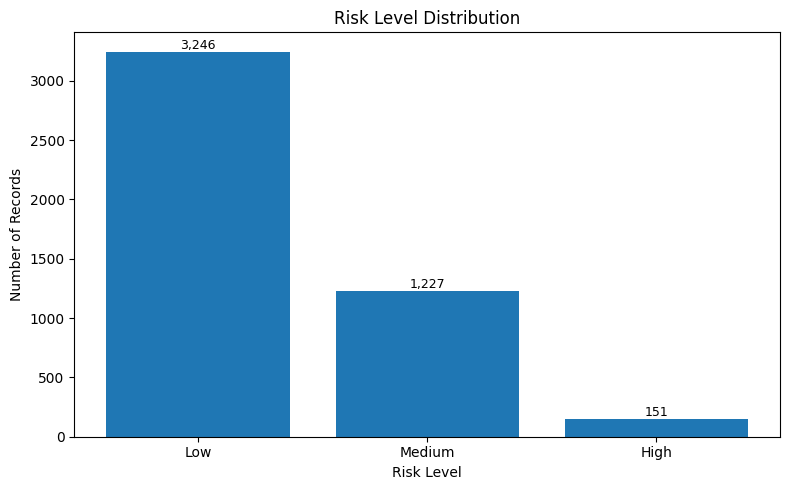

In [5]:
screenshots_folder = "../screenshots"
os.makedirs(screenshots_folder, exist_ok=True)

risk_counts = ml_data["Risk_Level"].value_counts()

risk_order = ["Low", "Medium", "High"]
risk_counts = risk_counts.reindex(risk_order).fillna(0)

plt.figure(figsize=(8, 5))

bars = plt.bar(risk_counts.index, risk_counts.values)

plt.title("Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Records")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.savefig(os.path.join(screenshots_folder, "07_ml_risk_distribution.png"))
plt.show()

STEP 5 - Split the Dataset

The dataset is split into training and testing data.

The model learns from the training data and is evaluated on the testing data.

In [6]:
X = ml_data[["County_Code", "Confirmed", "Year", "Month"]]
y = ml_data["Risk_Code"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))


Training records: 3699
Testing records: 925


STEP 6 - Train the Model

A Decision Tree model is trained to classify records into Low, Medium, or High risk.

In [7]:
model = DecisionTreeClassifier(
    random_state=42,
    max_depth=4
)

model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


STEP 7 - Evaluate the Model

The model is evaluated using accuracy and a classification report.

In [8]:
predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        predictions,
        target_names=risk_encoder.classes_
    )
)

Accuracy: 99.89 %

Classification Report:
              precision    recall  f1-score   support

        High       0.97      1.00      0.98        30
         Low       1.00      1.00      1.00       649
      Medium       1.00      1.00      1.00       246

    accuracy                           1.00       925
   macro avg       0.99      1.00      0.99       925
weighted avg       1.00      1.00      1.00       925



STEP 8 - Confusion Matrix

The confusion matrix shows correct and incorrect predictions for each risk level.

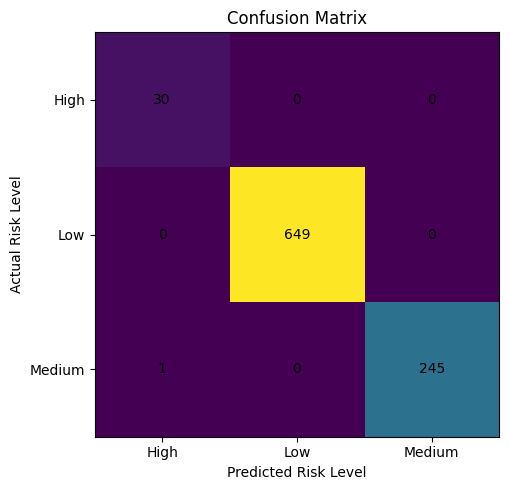

In [9]:
cm = confusion_matrix(y_test, predictions)

labels = risk_encoder.classes_

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Risk Level")
plt.ylabel("Actual Risk Level")

plt.xticks(range(len(labels)), labels)
plt.yticks(range(len(labels)), labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.savefig(os.path.join(screenshots_folder, "09_confusion_matrix.png"))
plt.show()

STEP 9 - Average Confirmed Cases by Risk Level

This chart shows the average number of confirmed cases for each risk level.

It helps explain how the risk categories are different from each other.

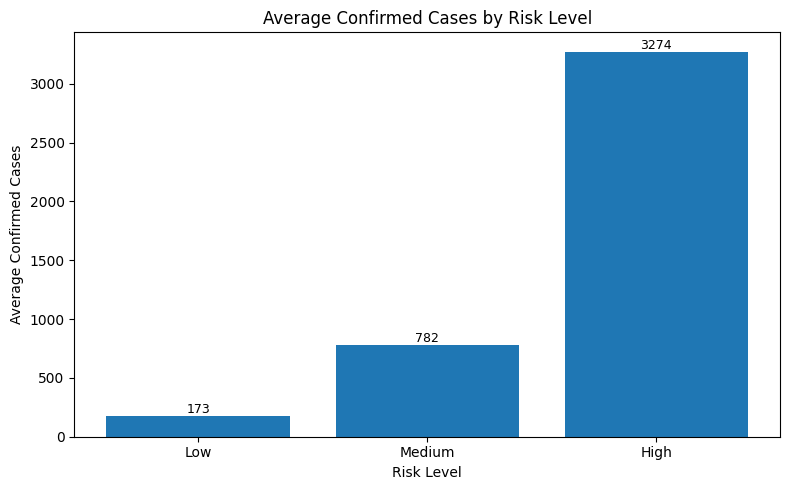

In [10]:
risk_avg = (
    ml_data
    .groupby("Risk_Level")["Confirmed"]
    .mean()
    .reindex(["Low", "Medium", "High"])
)

plt.figure(figsize=(8, 5))

bars = plt.bar(risk_avg.index, risk_avg.values)

plt.title("Average Confirmed Cases by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Average Confirmed Cases")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height():.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.savefig(os.path.join(screenshots_folder, "10_avg_confirmed_by_risk.png"))
plt.show()

STEP 10 - Test the Model with Example Data

The model is tested with simple example records.

In [11]:
example_data = pd.DataFrame({
    "County_Code": [
        county_encoder.transform(["Alba"])[0],
        county_encoder.transform(["Suceava"])[0],
        county_encoder.transform(["Mun. București"])[0]
    ],
    "Confirmed": [50, 1200, 4500],
    "Year": [2020, 2020, 2020],
    "Month": [4, 6, 7]
})

example_predictions = model.predict(example_data)
example_labels = risk_encoder.inverse_transform(example_predictions)

example_data["Predicted_Risk_Level"] = example_labels

example_data

,County_Code,Confirmed,Year,Month,Predicted_Risk_Level
0,0,50,2020,4,Low
1,35,1200,2020,6,Medium
2,27,4500,2020,7,High


STEP 11 - Machine Learning Summary

The model predicts the COVID-19 risk level using county-level data.

This satisfies the advanced analytics requirement because it applies predictive modeling.

In [12]:
print("Machine learning completed successfully.")
print("Screenshots saved:")
print("08_ml_risk_distribution.png")
print("09_confusion_matrix.png")
print("10_avg_confirmed_by_risk.png")

Machine learning completed successfully.
Screenshots saved:
08_ml_risk_distribution.png
09_confusion_matrix.png
10_avg_confirmed_by_risk.png
